# PART 2: CODING PROBLEMS

**Context:** A retailer rolled out same-day delivery in **some** stores (`treated=1`) in **2024**, but not others (`treated=0`). You have **two** years per store: **2023** (pre) and **2024** (post). Sales per store-year are simulated with a **true ATT** of **+5** (thousand dollars) on treated stores in the post year, on top of store fixed differences and a common time shock.

**Variables in `df_did`:**
- `store_id`: store identifier
- `year`: 2023 or 2024
- `treated`: 1 if the store received same-day delivery
- `post`: 1 if year == 2024
- `Y`: sales (thousands)

**Your tasks:**

1. Compute **cell means** $\bar{Y}$ for the four groups (treated/control $\times$ pre/post) and the **manual DID**: $(\bar{Y}_{T,post}-\bar{Y}_{T,pre})-(\bar{Y}_{C,post}-\bar{Y}_{C,pre})$.

2. Estimate the **saturated regression** $Y \sim \text{treated} + \text{post} + \text{treated} \times \text{post}$ (include a constant if you prefer an equivalent reparameterization — be consistent). Report $\hat{\beta}$ on the interaction and verify it matches the manual DID up to rounding.

3. **Plot** average $Y$ by `year` for treated vs control (two lines). Label axes and add a short title.

4. In 2–3 sentences, relate your plot to the parallel-trends idea (what would *violation* look like in the pre period if you had more pre years?).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")
rng = np.random.default_rng(5141)

n_treated = 40
n_control = 60
TRUE_ATT = 5.0

rows = []
for i in range(n_treated):
    sid = f"T{i}"
    alpha = rng.normal(12, 2)  # store fixed effect (treated stores differ in levels)
    for year, post in [(2023, 0), (2024, 1)]:
        delta_year = 1.5 if post else 0.0  # common time trend / shock
        treat_effect = TRUE_ATT if post else 0.0
        eps = rng.normal(0, 1.2)
        Y = alpha + delta_year + treat_effect + eps
        rows.append({"store_id": sid, "year": year, "treated": 1, "post": post, "Y": Y})

for j in range(n_control):
    sid = f"C{j}"
    alpha = rng.normal(10, 2)
    for year, post in [(2023, 0), (2024, 1)]:
        delta_year = 1.5 if post else 0.0
        eps = rng.normal(0, 1.2)
        Y = alpha + delta_year + eps
        rows.append({"store_id": sid, "year": year, "treated": 0, "post": post, "Y": Y})

df_did = pd.DataFrame(rows)
print("Simulated store-year panel (2 periods)")
print(f"  True ATT on treated in post: +{TRUE_ATT}")
print(df_did.head(8))

Simulated store-year panel (2 periods)
  True ATT on treated in post: +5.0
  store_id  year  treated  post          Y
0       T0  2023        1     0   9.473839
1       T0  2024        1     1  14.539162
2       T1  2023        1     0  12.093955
3       T1  2024        1     1  18.199726
4       T2  2023        1     0  15.489879
5       T2  2024        1     1  22.466538
6       T3  2023        1     0  11.032999
7       T3  2024        1     1  17.111704


In [4]:
# YOUR CODE for Problem 6
# 1. Four cell means + manual DID
cell_means = df_did.groupby(["treated", "post"])["Y"].mean().unstack()

Y_T_pre = cell_means.loc[1, 0]
Y_T_post = cell_means.loc[1, 1]
Y_C_pre = cell_means.loc[0, 0]
Y_C_post = cell_means.loc[0, 1]

manual_did = (Y_T_post - Y_T_pre) - (Y_C_post - Y_C_pre)

print("\nCell means:")
print(f"Treated, Pre  : {Y_T_pre:.3f}")
print(f"Treated, Post : {Y_T_post:.3f}")
print(f"Control, Pre  : {Y_C_pre:.3f}")
print(f"Control, Post : {Y_C_post:.3f}")
print(f"\nManual DID: {manual_did:.3f}")






Cell means:
Treated, Pre  : 11.617
Treated, Post : 18.572
Control, Pre  : 9.534
Control, Post : 11.010

Manual DID: 5.479


In [5]:
# 2. OLS: Y ~ treated + post + treated*post (use sm.add_constant or equivalent)
df_did["treated_post"] = df_did["treated"] * df_did["post"]

X = df_did[["treated", "post", "treated_post"]]
X = sm.add_constant(X)
y = df_did["Y"]

model = sm.OLS(y, X).fit()

beta_interaction = model.params["treated_post"]

print("\nRegression results:")
print(model.summary())
print(f"\nInteraction coefficient (treated × post): {beta_interaction:.3f}")
print(f"Difference between regression DID and manual DID: {beta_interaction - manual_did:.10f}")




Regression results:
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     123.5
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           6.08e-45
Time:                        19:52:38   Log-Likelihood:                -457.57
No. Observations:                 200   AIC:                             923.1
Df Residuals:                     196   BIC:                             936.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            9.5338    

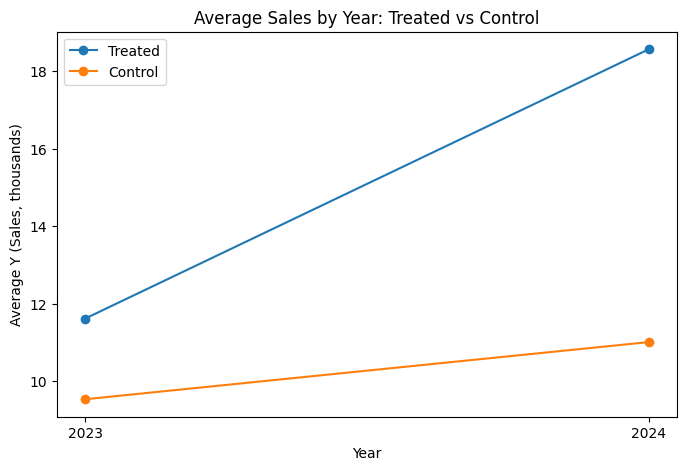

In [ ]:
# 3. Line plot: mean Y by year, separate lines for treated vs control
plot_df = df_did.groupby(["year", "treated"])["Y"].mean().reset_index()

treated_line = plot_df[plot_df["treated"] == 1]
control_line = plot_df[plot_df["treated"] == 0]

plt.figure(figsize=(8, 5))
plt.plot(treated_line["year"], treated_line["Y"], marker="o", label="Treated")
plt.plot(control_line["year"], control_line["Y"], marker="o", label="Control")
plt.xlabel("Year")
plt.ylabel("Average Y (Sales, thousands)")
plt.title("Average Sales by Year: Treated vs Control")
plt.xticks([2023, 2024])
plt.legend()

# 4. Brief written answer in a markdown cell below (or as comments)

The figure shows that both groups trend upward, while the treated group increases more after treatment. However, with only one pre-period, the parallel-trends assumption cannot be verified directly. A violation would mean the two groups already had different trends before 2024.
